In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load processed CSV
df = pd.read_csv(os.path.join("..", "data", "processed", "cardio_onc_prostate_03cleaned.csv"))

(239, 48)


# Number of patients on each NHT

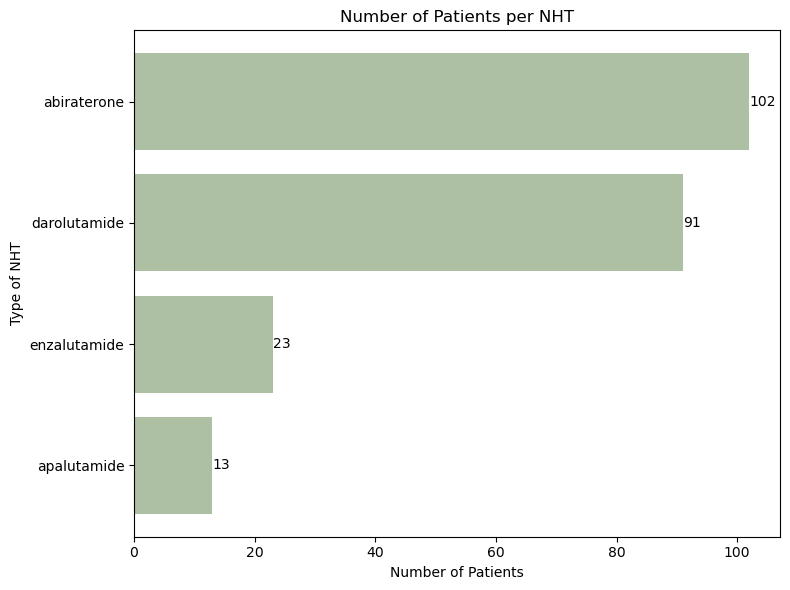

In [99]:
# Standardize case of specific_nht_used
df['specific_nht_used'] = df['specific_nht_used'].str.lower()

# Count unique patients per NHT
num_patients = df.groupby('specific_nht_used')['unique_patient_id'].nunique()

# There are a couple spelling errors we need to correct later. Omit for now.
num_patients = num_patients[num_patients > 1]
num_patients = num_patients.sort_values(ascending=True)

#print(num_patients)

fig, ax = plt.subplots(figsize=(8,6))

ax.barh(num_patients.index, num_patients.values)
p=ax.barh(num_patients.index, num_patients.values, color='#aec0a3')
ax.bar_label(p, label_type='edge')
ax.set_ylabel('Type of NHT')
ax.set_xlabel('Number of Patients')
ax.set_title('Number of Patients per NHT')
plt.tight_layout()
plt.show()

# Additional ideas: show percentages and counts

# Number of patients on each ADT

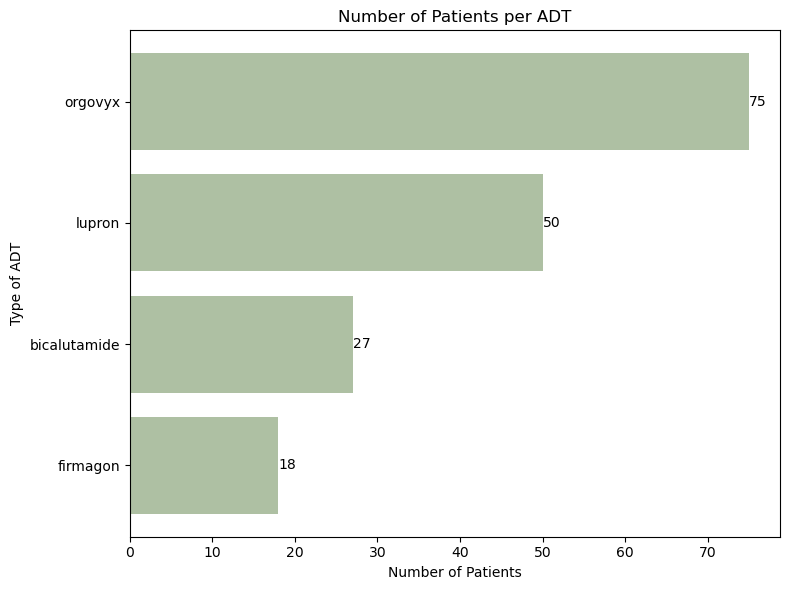

In [100]:
# Standardize case of adt_agent
df['adt_agent'] = df['adt_agent'].str.lower()

# Count unique patients per NHT
num_patients = df.groupby('adt_agent')['unique_patient_id'].nunique()

# There are some misspellings and some patients who were on multiple drugs. Omit them for now.
num_patients = num_patients[num_patients > 3]
num_patients = num_patients.sort_values(ascending=True)

#print(num_patients)

fig, ax = plt.subplots(figsize=(8,6))

ax.barh(num_patients.index, num_patients.values)
p=ax.barh(num_patients.index, num_patients.values, color='#aec0a3')
ax.bar_label(p, label_type='edge')
ax.set_ylabel('Type of ADT')
ax.set_xlabel('Number of Patients')
ax.set_title('Number of Patients per ADT')
plt.tight_layout()
plt.show()

# Additional ideas: show percentages

# Distribution of toxicities

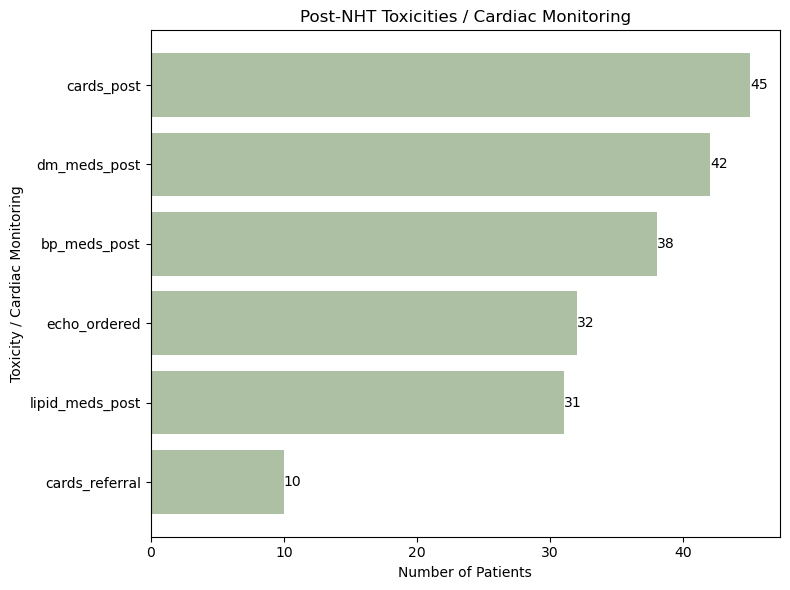

In [121]:
counts = {
    'bp_meds_post': (df['bp_meds_post'] != 0).sum(),
    'lipid_meds_post': (df['lipid_meds_post'] !=0).sum(),
    'dm_meds_post': (df['dm_meds_post'] != 0).sum(),
    'cards_post': (df['cards_post'] == 1).sum(),
    'cards_referral': (df['cards_referral'] == 1).sum(),
    'echo_ordered': (df['echo_ordered'] == 1).sum(),
}

counts = dict(sorted(counts.items(), key=lambda item: item[1]))

labels = list(counts.keys())
values = list(counts.values())

fig, ax = plt.subplots(figsize=(8,6))
bars = ax.barh(labels, values, color='#aec0a3')

ax.bar_label(bars)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Toxicity / Cardiac Monitoring')
ax.set_title('Post-NHT Toxicities / Cardiac Monitoring')
plt.tight_layout()
plt.show()

# Cardiovascular toxicities by NHT

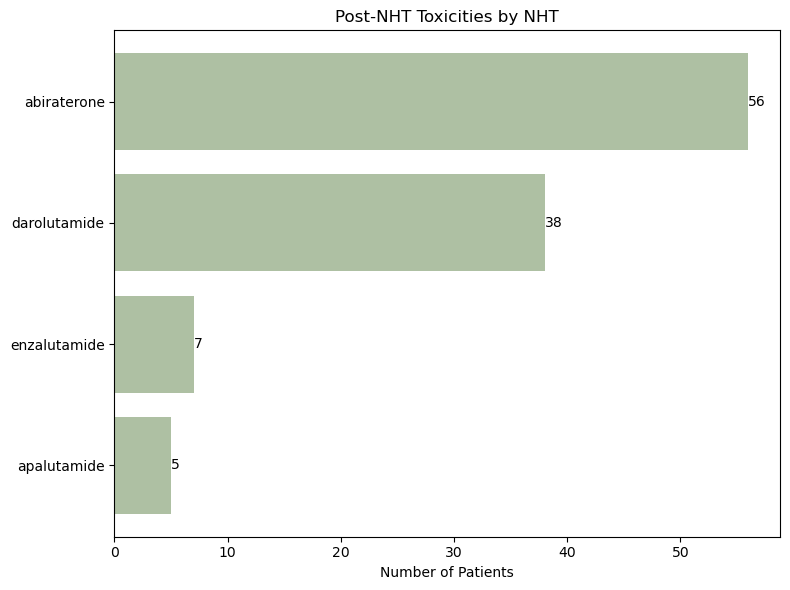

In [133]:
df['specific_nht_used'] = df['specific_nht_used'].str.lower()
df = df.dropna(subset=['specific_nht_used'])

nht_list = df['specific_nht_used'].unique()

nht_counts = dict.fromkeys(nht_list, 0)

for nht in nht_counts.keys():
    nht_counts[nht] += (df[df['specific_nht_used']==nht]['bp_meds_post'] != 0).sum()
    nht_counts[nht] += (df[df['specific_nht_used']==nht]['lipid_meds_post'] !=0).sum()
    nht_counts[nht] += (df[df['specific_nht_used']==nht]['dm_meds_post'] != 0).sum()
    #nht_counts[nht] += (df[df['specific_nht_used']==nht]['cards_post'] == 1).sum()
    #nht_counts[nht] += (df[df['specific_nht_used']==nht]['cards_referral'] == 1).sum()
    #nht_counts[nht] += (df[df['specific_nht_used']==nht]['echo_ordered'] == 1).sum()

# There are some spelling errors. Omit them for now.
nht_counts = {k: v for k, v in nht_counts.items() if v >= 3}
nht_counts = dict(sorted(nht_counts.items(), key=lambda item: item[1]))

labels = list(nht_counts.keys())
values = list(nht_counts.values())

fig, ax = plt.subplots(figsize=(8,6))

bars = ax.barh(labels, values, color='#aec0a3')

ax.bar_label(bars)

ax.set_xlabel('Number of Patients')
ax.set_title('Post-NHT Toxicities by NHT')
plt.tight_layout()
plt.show()

# Cardiovascular Toxicities by ADT

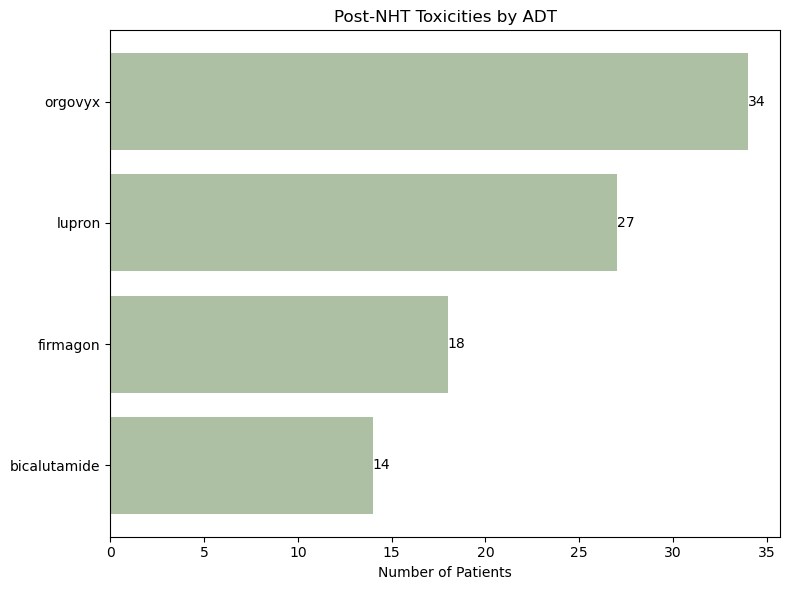

In [135]:
df['adt_agent'] = df['adt_agent'].str.lower()
df = df.dropna(subset=['adt_agent'])

adt_list = df['adt_agent'].unique()

adt_counts = dict.fromkeys(adt_list, 0)

for adt in adt_counts.keys():
    adt_counts[adt] += (df[df['adt_agent']==adt]['bp_meds_post'] != 0).sum()
    adt_counts[adt] += (df[df['adt_agent']==adt]['lipid_meds_post'] !=0).sum()
    adt_counts[adt] += (df[df['adt_agent']==adt]['dm_meds_post'] != 0).sum()
    #adt_counts[adt] += (df[df['adt_agent']==adt]['cards_post'] == 1).sum()
    #adt_counts[adt] += (df[df['adt_agent']==adt]['cards_referral'] == 1).sum()
    #adt_counts[adt] += (df[df['adt_agent']==adt]['echo_ordered'] == 1).sum()

# There are some spelling errors. Omit them for now. Also omit multiple ADTs.
adt_counts = {k: v for k, v in adt_counts.items() if v > 4}
adt_counts = dict(sorted(adt_counts.items(), key=lambda item: item[1]))

labels = list(adt_counts.keys())
values = list(adt_counts.values())

fig, ax = plt.subplots(figsize=(8,6))

bars = ax.barh(labels, values, color='#aec0a3')

ax.bar_label(bars)

ax.set_xlabel('Number of Patients')
ax.set_title('Post-NHT Toxicities by ADT')
plt.tight_layout()
plt.show()

# Toxicities by NHT

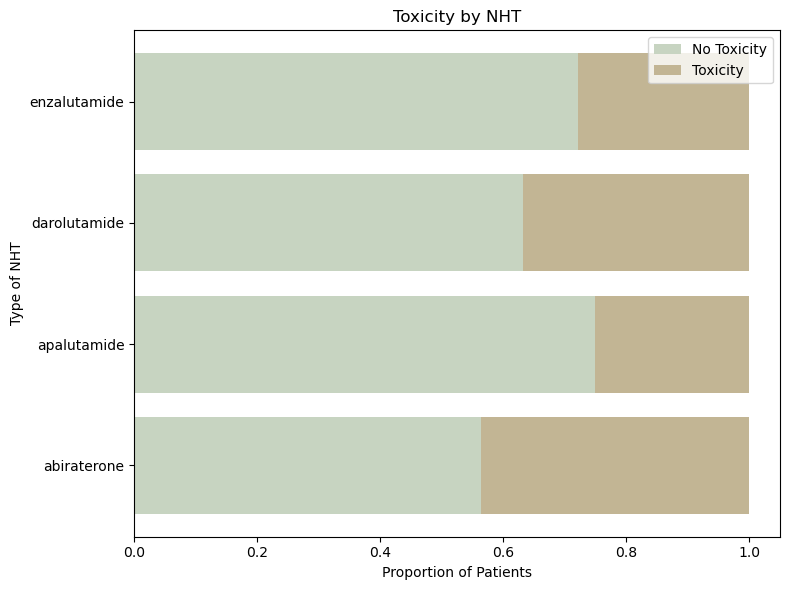

In [136]:
toxicity_cols = [
    'bp_meds_post', 'lipid_meds_post', 'dm_meds_post',
    'cards_post', 'cards_referral', 'echo_ordered', 'ecg_done'
]

df['specific_nht_used'] = df['specific_nht_used'].str.lower()

# patient has toxicity if ANY condition is met
df['toxicity'] = (
    (df['bp_meds_post'] != 0) |
    (df['lipid_meds_post'] != 0) |
    (df['dm_meds_post'] != 0)
    #|(df['cards_post'] == 1) |
    #(df['cards_referral'] == 1) |
    #(df['echo_ordered'] == 1)
)

counts = (
    df.groupby(['specific_nht_used', 'toxicity'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts[counts.sum(axis=1) >= 5]

fig, ax = plt.subplots(figsize=(8,6))
props = counts.div(counts.sum(axis=1), axis=0)
ax.barh(props.index, props[False], label='No Toxicity', color='#c7d4c1')
ax.barh(props.index, props[True], left=props[False], color='#c2b594', label='Toxicity')

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Toxicity by NHT')
ax.legend()

plt.tight_layout()
plt.show()

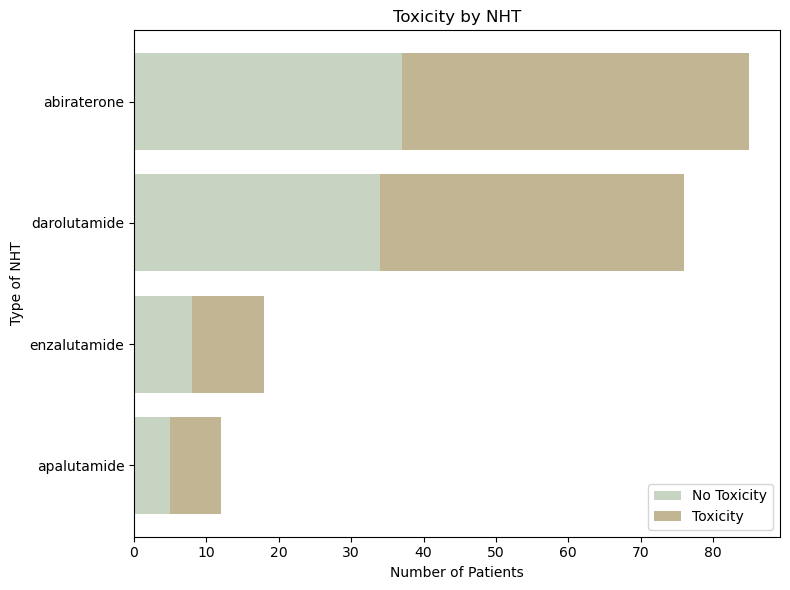

In [131]:

# Standardize NHT names
df['specific_nht_used'] = df['specific_nht_used'].str.lower()

# Define toxicity indicator
df['toxicity'] = (
    (df['bp_meds_post'] != 0) |
    (df['lipid_meds_post'] != 0) |
    (df['dm_meds_post'] != 0) |
    (df['cards_post'] == 1) |
    (df['cards_referral'] == 1) |
    (df['echo_ordered'] == 1)
)

# Count unique patients by NHT and toxicity
counts = (
    df.groupby(['specific_nht_used', 'toxicity'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Remove NHTs with <5 patients
counts = counts[counts.sum(axis=1) >= 5]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(8,6))

ax.barh(counts.index, counts[False], color='#c7d4c1', label='No Toxicity')
ax.barh(counts.index, counts[True], left=counts[False], color='#c2b594', label='Toxicity')
ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Toxicity by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Toxicity by ADT

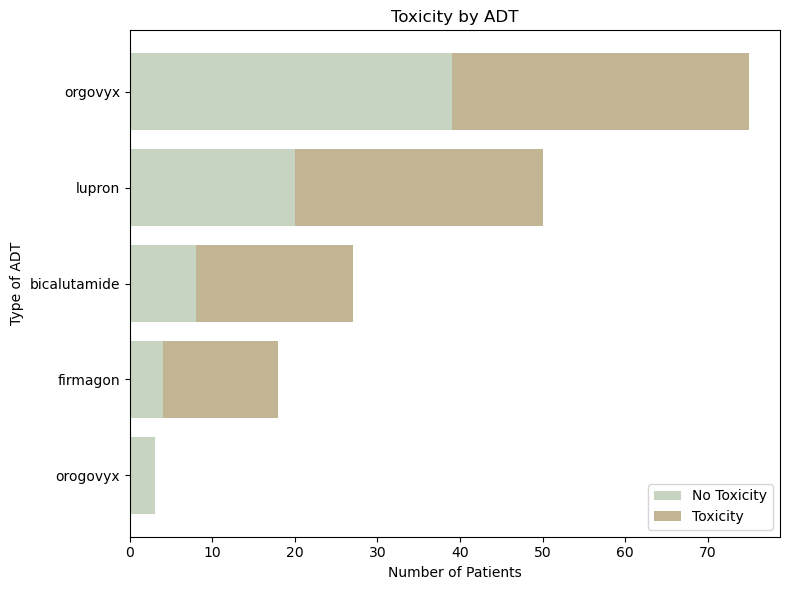

In [132]:

df['adt_agent'] = df['adt_agent'].str.lower()

# Define toxicity indicator
df['toxicity'] = (
    (df['bp_meds_post'] != 0) |
    (df['lipid_meds_post'] != 0) |
    (df['dm_meds_post'] != 0) |
    (df['cards_post'] == 1) |
    (df['cards_referral'] == 1) |
    (df['echo_ordered'] == 1)
)

# Count unique patients by ADT and toxicity
counts = (
    df.groupby(['adt_agent', 'toxicity'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Remove ADTs with <3 patients
counts = counts[counts.sum(axis=1) >= 3]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(8,6))

ax.barh(counts.index, counts[False], color='#c7d4c1', label='No Toxicity')
ax.barh(counts.index, counts[True], left=counts[False], color='#c2b594', label='Toxicity')

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of ADT')
ax.set_title('Toxicity by ADT')
ax.legend()

plt.tight_layout()
plt.show()